In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

## Data loading

In [40]:
data_o_vib = pd.read_csv("data/Musical training and Pitch perception - O -_ Vib (respuestas) - Respuestas de formulario 1.csv")
data_vib_o = pd.read_csv("data/Musical training and Pitch perception - Vib -_ O - Respuestas de formulario 1.csv")

total_data = pd.concat([data_o_vib, data_vib_o], ignore_index=True)

total_data = total_data.set_axis(['temp',
       'MusicalTraining',
       'Instrument',
       'SkillProfeciency',
       'TrainingYears',
       'HighestMusicStudy',
       'PracticeNow',
       'RegularPractice', '(+)9 200 og',
       '(+)11 200 og', '(-)7 200 og', '(+)14 200 og', '(-)13 200 og',
       '(-)8 200 og', '(-)5 200 og', '(+)6 200 og', '(+)10 200 og',
       '(-)15 200 og', '(+)12 200 og', '(+)30 200 og', '(+)6 200 vib',
       '(-)13 200 vib', '(+)12 200 vib', '(+)30 200 vib', '(+)10 200 vib',
       '(-)15 200 vib', '(+)9 200 vib', '(-)7 200 vib', '(-)8 200 vib ',
       '(+)11 200 vib', '(-)5 200 vib', '(+)14 200 vib', '(-)5 400 og ',
       '(+)14 400 og', '(+)6 400 og', '(+)12 400 og', '(-)8 400 og',
       '(-)13 400 og', '(+)9 400 og', '(+)11 400 og', '(+)30 400 og',
       '(-)15 400 og', '(+)10 400 og', '(-)7 400 og', '(-)7 400 vib',
       '(+)11 400 vib', '(-)15 400 vib', '(-)8 400 vib', '(+)6 400 vib',
       '(-)13 400 vib', '(-)5 400 vib', '(+)9 400 vib', '(+)10 400 vib',
       '(+)12 400 vib', '(+)30 400 vib', '(+)14 400 vib', '(+)9 1200 og',
       '(-)15 1200 og', '(+)14 1200 og', '(+)10 1200 og', '(+)12 1200 og',
       '(+)6 1200 og', '(-)5 1200 og', '(+)30 1200 og', '(+)11 1200 og',
       '(-)8 1200 og', '(-)7 1200 og', '(-)13 1200 og', '(-)13 1200 vib',
       '(+)14 1200 vib', '(+)12 1200 vib', '(+)9 1200 vib', '(-)15 1200 vib',
       '(-)5 1200 vib', '(-)7 1200 vib', '(+)30 1200 vib', '(+)11 1200 vib',
       '(+)10 1200 vib', '(+)6 1200 vib', '(-)8 1200 vib'], axis=1)

total_data["Instrument"] = total_data["Instrument"].fillna("None")
total_data["HighestMusicStudy"] = total_data["HighestMusicStudy"].fillna("None")

In [41]:
display(data_o_vib.head())
display(data_vib_o.head())
display(total_data.head())

,Marca temporal,"Do you have any musical training (musician, producer, recorder...)?","If so, which instrument do you play/are you familiar with or what kind of training do you have?",How would you rate your skill on your primary instrument?,How many years of formal music training have you had?,What is the highest level of music theory you have studied?,Do you still practice music nowadays?,"If so, how often do you practice music?",(+)9 200 og,(+)11 200 og,...,(+)12 1200 vib,(+)9 1200 vib,(-)15 1200 vib,(-)5 1200 vib,(-)7 1200 vib,(+)30 1200 vib,(+)11 1200 vib,(+)10 1200 vib,(+)6 1200 vib,(-)8 1200 vib
0,21/01/2026 10:56:18,Yes,clarinet,Beginner,4-6 years,"Basic (e.g., notes, rhythms)",Yes,Rarely,Equal,Equal,...,Acending,Acending,Descending,Equal,Descending,Acending,Acending,Acending,Acending,Equal
1,21/01/2026 11:28:43,No,NaN,I don't play any instrument,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Equal,Equal,Descending,Descending,Equal,Acending,Acending,Equal,Equal,Equal
2,21/01/2026 13:08:31,No,NaN,I don't play any instrument,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Acending,Acending,Descending,Descending,Descending,Acending,Equal,Acending,Descending,Descending
3,21/01/2026 13:08:31,Not sure,piano,Beginner,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Acending,Acending,Descending,Descending,Descending,Acending,Equal,Acending,Descending,Descending
4,21/01/2026 14:56:12,Yes,piano,Intermediate,4-6 years,"Intermediate (e.g., key signatures, harmony)",Yes,A few times a week,Equal,Acending,...,Acending,Acending,Equal,Equal,Equal,Acending,Acending,Equal,Acending,Descending


,Marca temporal,"Do you have any musical training (musician, producer, recorder...)?","If so, which instrument do you play/are you familiar with or what kind of training do you have?",How would you rate your skill on your primary instrument?,How many years of formal music training have you had?,What is the highest level of music theory you have studied?,Do you still practice music nowadays?,"If so, how often do you practice music?",(+)6 200 vib,(-)13 200 vib,...,(+)14 1200 og,(+)10 1200 og,(+)12 1200 og,(+)6 1200 og,(-)5 1200 og,(+)30 1200 og,(+)11 1200 og,(-)8 1200 og,(-)7 1200 og,(-)13 1200 og
0,21/01/2026 11:18:33,Yes,guitar,Advanced,1-3 years,NaN,Yes,Daily,Descending,Equal,...,Acending,Acending,Acending,Acending,Descending,Acending,Acending,Descending,Descending,Descending
1,21/01/2026 13:36:32,Yes,piano,Advanced,10+ years,"Advanced (e.g., counterpoint, analysis)",Yes,Daily,Equal,Equal,...,Acending,Acending,Acending,Equal,Equal,Acending,Acending,Equal,Acending,Descending
2,21/01/2026 15:52:05,Yes,voice/ production,Intermediate,7-9 years,"Basic (e.g., notes, rhythms)",Yes,A few times a month,Equal,Descending,...,Acending,Acending,Acending,Equal,Equal,Acending,Equal,Descending,Equal,Descending
3,21/01/2026 18:45:19,Yes,piano,Beginner,4-6 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Equal,Equal,Equal,Descending,Descending,Acending,Acending,Descending,Descending,Descending
4,21/01/2026 18:54:06,No,NaN,I don't play any instrument,0 years,NaN,Yes,A few times a week,Equal,Equal,...,Descending,Acending,Acending,Equal,Equal,Acending,Equal,Descending,Equal,Equal


,temp,MusicalTraining,Instrument,SkillProfeciency,TrainingYears,HighestMusicStudy,PracticeNow,RegularPractice,(+)9 200 og,(+)11 200 og,...,(+)12 1200 vib,(+)9 1200 vib,(-)15 1200 vib,(-)5 1200 vib,(-)7 1200 vib,(+)30 1200 vib,(+)11 1200 vib,(+)10 1200 vib,(+)6 1200 vib,(-)8 1200 vib
0,21/01/2026 10:56:18,Yes,clarinet,Beginner,4-6 years,"Basic (e.g., notes, rhythms)",Yes,Rarely,Equal,Equal,...,Acending,Acending,Descending,Equal,Descending,Acending,Acending,Acending,Acending,Equal
1,21/01/2026 11:28:43,No,None,I don't play any instrument,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Equal,Equal,Descending,Descending,Equal,Acending,Acending,Equal,Equal,Equal
2,21/01/2026 13:08:31,No,None,I don't play any instrument,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Acending,Acending,Descending,Descending,Descending,Acending,Equal,Acending,Descending,Descending
3,21/01/2026 13:08:31,Not sure,piano,Beginner,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Acending,Acending,Descending,Descending,Descending,Acending,Equal,Acending,Descending,Descending
4,21/01/2026 14:56:12,Yes,piano,Intermediate,4-6 years,"Intermediate (e.g., key signatures, harmony)",Yes,A few times a week,Equal,Acending,...,Acending,Acending,Equal,Equal,Equal,Acending,Acending,Equal,Acending,Descending


## General statistics of our population

In [42]:
print(f"Number of participants with steady first: {data_o_vib.shape[0]}")
print(f"Number of participants with vibrato first: {data_vib_o.shape[0]}")
print(f"Total number of participants: {total_data.shape[0]}")

Number of participants with steady first: 24
Number of participants with vibrato first: 19
Total number of participants: 43


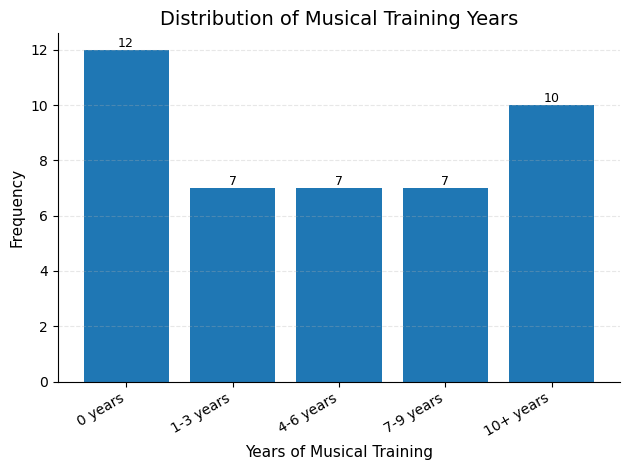

In [66]:

musical_training_years = total_data["TrainingYears"]

# Desired order
order = ["0 years", "1-3 years", "4-6 years", "7-9 years", "10+ years"]

# Count and reorder
counts = musical_training_years.value_counts().reindex(order)

plt.figure()

bars = plt.bar(counts.index, counts.values)

# Title and labels
plt.title("Distribution of Musical Training Years", fontsize=14)
plt.xlabel("Years of Musical Training", fontsize=11)
plt.ylabel("Frequency", fontsize=11)

# Rotate x labels
plt.xticks(rotation=30, ha="right")

# Light grid
plt.grid(axis="y", alpha=0.3, linestyle="--")

# Remove top/right spines for cleaner look
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [44]:
total_data.head()

,temp,MusicalTraining,Instrument,SkillProfeciency,TrainingYears,HighestMusicStudy,PracticeNow,RegularPractice,(+)9 200 og,(+)11 200 og,...,(+)12 1200 vib,(+)9 1200 vib,(-)15 1200 vib,(-)5 1200 vib,(-)7 1200 vib,(+)30 1200 vib,(+)11 1200 vib,(+)10 1200 vib,(+)6 1200 vib,(-)8 1200 vib
0,21/01/2026 10:56:18,Yes,clarinet,Beginner,4-6 years,"Basic (e.g., notes, rhythms)",Yes,Rarely,Equal,Equal,...,Acending,Acending,Descending,Equal,Descending,Acending,Acending,Acending,Acending,Equal
1,21/01/2026 11:28:43,No,None,I don't play any instrument,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Equal,Equal,Descending,Descending,Equal,Acending,Acending,Equal,Equal,Equal
2,21/01/2026 13:08:31,No,None,I don't play any instrument,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Acending,Acending,Descending,Descending,Descending,Acending,Equal,Acending,Descending,Descending
3,21/01/2026 13:08:31,Not sure,piano,Beginner,0 years,"Basic (e.g., notes, rhythms)",No,I don't practice music,Equal,Equal,...,Acending,Acending,Descending,Descending,Descending,Acending,Equal,Acending,Descending,Descending
4,21/01/2026 14:56:12,Yes,piano,Intermediate,4-6 years,"Intermediate (e.g., key signatures, harmony)",Yes,A few times a week,Equal,Acending,...,Acending,Acending,Equal,Equal,Equal,Acending,Acending,Equal,Acending,Descending


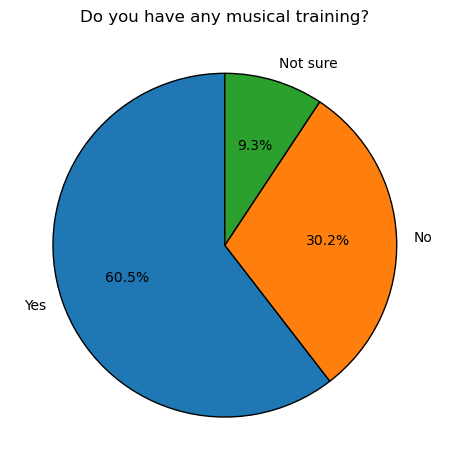

In [ ]:
instrument_distribution = total_data["MusicalTraining"]

# Count and reorder
counts = instrument_distribution.value_counts()

plt.figure()

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
        wedgeprops={'edgecolor': 'black'}
)

plt.title("Do you have any musical training?")

plt.tight_layout()
plt.show()

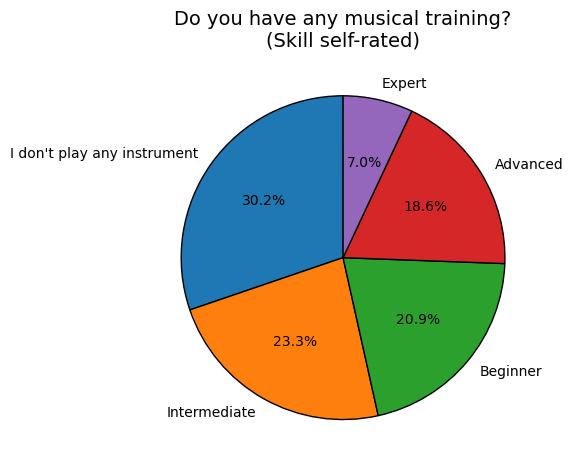

In [ ]:
skill_proficieny = total_data["SkillProfeciency"]

# Count and reorder
counts = skill_proficieny.value_counts()

plt.figure()

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
        wedgeprops={'edgecolor': 'black'}
)

plt.title("Do you have any musical training?\n(Skill self-rated)",fontsize=14)

plt.tight_layout()
plt.show()

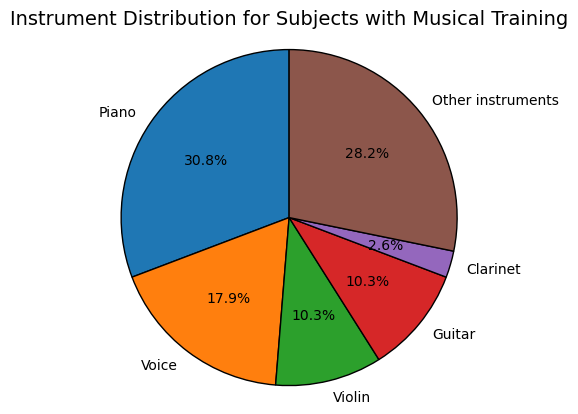

In [72]:
instruments = (
    total_data[total_data['MusicalTraining'].isin(['Yes'])]["Instrument"]
    .str.lower()
    .str.split("/")
)

exploded = instruments.explode().str.strip()

counts = exploded.value_counts()


top_n = 5
top_counts = counts[:top_n]
other_sum = counts[top_n:].sum()

final_counts = pd.concat([
    top_counts,
    pd.Series({"Other instruments": other_sum})
])

plt.figure()

plt.pie(
    final_counts.values,
    labels=final_counts.index.str.capitalize(),
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)
plt.axis('equal')  # Makes it a perfect circle


plt.axis("equal")
plt.title("Instrument Distribution for Subjects with Musical Training",fontsize=14)
plt.show()

## JND-related results

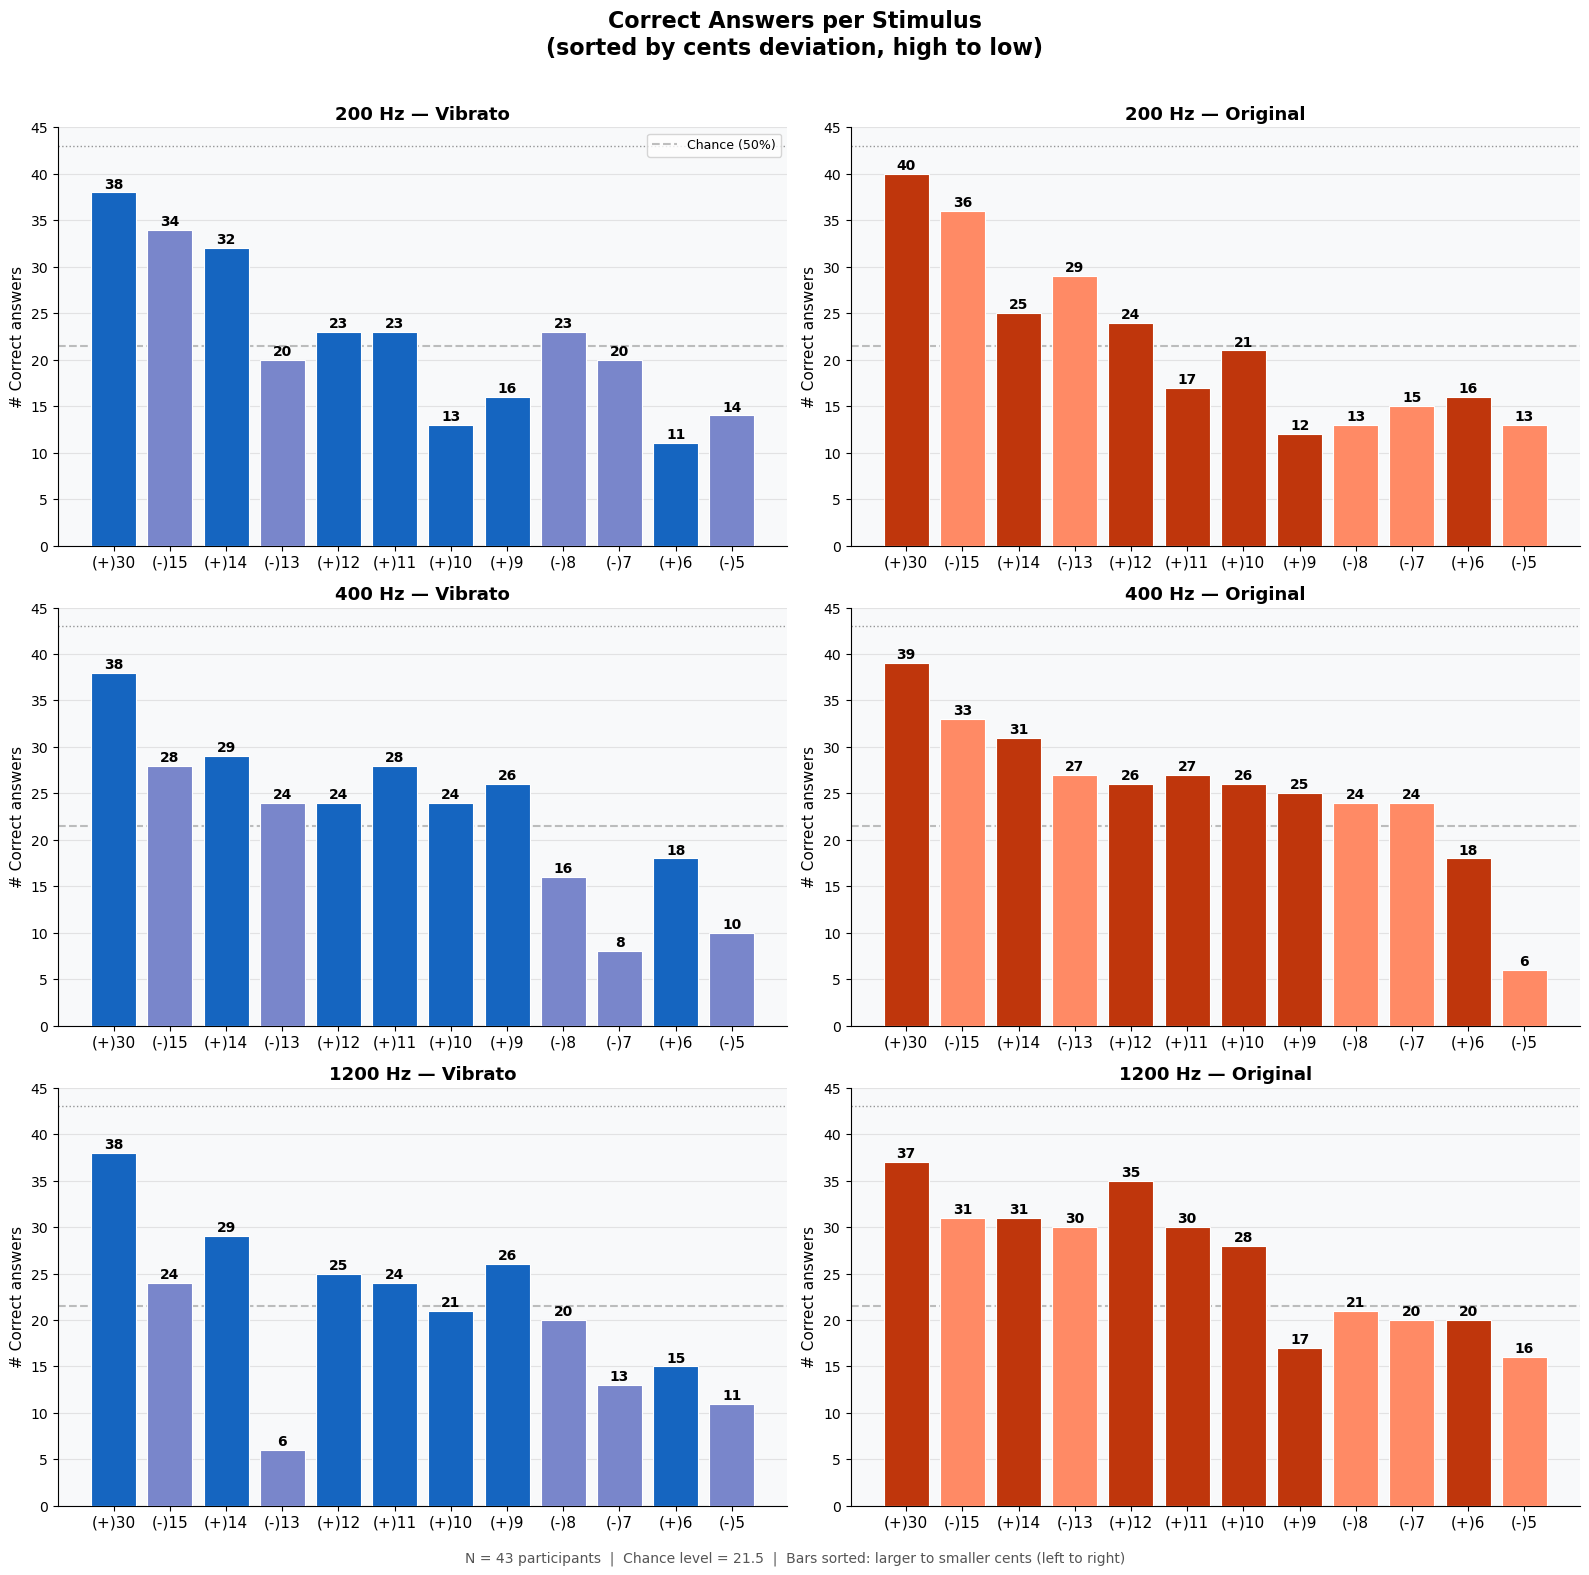

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# ── 2. Identify stimulus columns (everything after the first 8 metadata cols) ─
total_stim_cols = total_data.columns[8:]
n_participants = len(total_data)

# ── 3. Parse each stimulus column and count correct answers ───────────────────
results = []
for col in total_stim_cols:
    col_stripped = col.strip()
    sign = '+' if col_stripped.startswith('(+)') else '-'
    parts = col_stripped.replace('(+)', '').replace('(-)', '').strip().split()
    cents = int(parts[0])
    freq  = int(parts[1])
    typ   = parts[2]   # 'vib' or 'og'

    # Correct answer: Ascending for (+), Descending for (-)
    if sign == '+':
        correct = (total_data[col] == 'Acending').sum()
    else:
        correct = (total_data[col] == 'Descending').sum()

    signed_cents = cents if sign == '+' else -cents
    label = f"(+){cents}" if sign == '+' else f"(-){cents}"
    results.append({
        'sign': sign, 'cents': cents, 'signed_cents': signed_cents,
        'freq': freq, 'type': typ, 'correct': correct, 'label': label
    })

res_df = pd.DataFrame(results)

# ── 4. Plot ───────────────────────────────────────────────────────────────────
freqs        = [200, 400, 1200]
types_labels = {'vib': 'Vibrato', 'og': 'Original'}

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle(
    'Correct Answers per Stimulus\n(sorted by cents deviation, high to low)',
    fontsize=16, fontweight='bold', y=0.98
)

for row_idx, freq in enumerate(freqs):
    for col_idx, typ in enumerate(['vib', 'og']):
        ax = axes[row_idx, col_idx]

        subset = res_df[(res_df['freq'] == freq) & (res_df['type'] == typ)].copy()
        # Sort from bigger to smaller cents (positive first, then negative)
        subset = subset.sort_values('cents', ascending=False)

        x_labels = subset['label'].tolist()
        y_vals   = subset['correct'].tolist()
        signed   = subset['signed_cents'].tolist()

        # Darker shade for positive cents, lighter for negative
        pos_color = '#1565C0' if typ == 'vib' else '#BF360C'
        neg_color = '#7986CB' if typ == 'vib' else '#FF8A65'
        bar_colors = [pos_color if s > 0 else neg_color for s in signed]

        bars = ax.bar(
            range(len(x_labels)), y_vals,
            color=bar_colors, edgecolor='white', linewidth=0.8, zorder=3
        )

        # Value labels on top of each bar
        for bar, val in zip(bars, y_vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.15,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold'
            )

        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels, fontsize=11)
        ax.set_ylim(0, n_participants + 2)
        ax.set_ylabel('# Correct answers', fontsize=11)
        ax.set_title(f'{freq} Hz — {types_labels[typ]}', fontsize=13, fontweight='bold')

        # Chance level line
        ax.axhline(y=n_participants / 2, color='gray', linestyle='--',
                   alpha=0.5, label='Chance (50%)', zorder=2)
        ax.axhline(y=n_participants, color='black', linestyle=':',
                   alpha=0.4, linewidth=1, zorder=2)

        ax.set_facecolor('#F8F9FA')
        ax.grid(axis='y', alpha=0.3, zorder=1)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=9)

fig.text(
    0.5, 0.01,
    f'N = {n_participants} participants  |  Chance level = {n_participants / 2:.1f}'
    f'  |  Bars sorted: larger to smaller cents (left to right)',
    ha='center', fontsize=10, color='#555555'
)

plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.show()